# Stage 7 — SARIMAX

SARIMAX (seasonal ARIMA with exogenous regressors) lands behind the
Stage 4 `Model` protocol.  This notebook is the pedagogical surface:
seasonal decomposition makes the weekly + daily structure visible, a
small AIC sweep justifies the shipped order, `plot_diagnostics` +
`summary` demonstrate the fit surface, and the Stage 6 `acf_residuals`
helper renders the **narrative payoff** — the lag-168 spike that the
linear baseline left in the residuals is absorbed by the weekly
Fourier + daily-seasonal SARIMAX.

- **Intent:** [`docs/intent/07-sarimax.md`](../docs/intent/07-sarimax.md)
- **Plan:** [`docs/plans/completed/07-sarimax.md`](../docs/plans/completed/07-sarimax.md)
- **Previous stage:** Stage 6 enhanced evaluation (diagnostic-plot library
  and the ACF lag-168 reference marker this notebook's Cell 9 pays off).

Plan decisions applied here: D1 (dynamic harmonic regression — Fourier
pairs at period 168, seasonal order at s=24), D2 (`order=(1,0,1),
seasonal_order=(1,1,1,24)`), D3 (51 exog columns: `temperature_2m` +
44 calendar one-hots + 6 Fourier weekly harmonics), D4 (fixed sliding
window, weekly stride; shrunk here for notebook budget), D7 (no
parametric CI plot — empirical q10-q90 band lands in Stage 10),
D8 (reuse Stage 6 `acf_residuals` + statsmodels `plot_diagnostics`).


In [1]:
import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # cache_dir values resolve against cwd

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from statsmodels.tsa.seasonal import STL  # noqa: E402
from statsmodels.tsa.statespace.sarimax import SARIMAX  # noqa: E402
from statsmodels.tsa.stattools import adfuller  # noqa: E402

from bristol_ml import load_config  # noqa: E402
from bristol_ml.evaluation import plots  # noqa: E402
from bristol_ml.evaluation.harness import evaluate  # noqa: E402
from bristol_ml.evaluation.metrics import METRIC_REGISTRY  # noqa: E402
from bristol_ml.features import assembler  # noqa: E402
from bristol_ml.models.linear import LinearModel  # noqa: E402
from bristol_ml.models.naive import NaiveModel  # noqa: E402
from bristol_ml.models.sarimax import SarimaxModel  # noqa: E402
from conf._schemas import LinearConfig, NaiveConfig  # noqa: E402

# Apply the Okabe-Ito palette + figsize defaults (Stage 6 D2 / D5).
plots.apply_plots_config(
    load_config(
        config_path=REPO_ROOT / "conf",
        overrides=["model=sarimax"],
    ).evaluation.plots
)

# Plan D4 splitter override — fixed sliding window + weekly-ish stride.
# The project default is `min_train_periods=8760` (one year); the
# `weather_calendar` cache is exactly one year (8760 rows), so the
# notebook shrinks the window to 30 days and strides ~8-weekly so the
# rolling-origin evaluation stays inside the 10-minute budget (plan
# AC-3; Cell 6 budget check).  The CLI path inherits the full-year
# defaults for reporting-quality output.
cfg = load_config(
    config_path=REPO_ROOT / "conf",
    overrides=[
        "model=sarimax",
        "features=weather_calendar",
        "evaluation.rolling_origin.fixed_window=true",
        "evaluation.rolling_origin.min_train_periods=720",
        "evaluation.rolling_origin.step=1344",
        # test_len=168 (one week) gives enough per-fold horizon for the
        # Cell 9 ACF plot to reach lag 168; 6 folds x 168 = 1008 samples.
        "evaluation.rolling_origin.test_len=168",
    ],
)
assert cfg.features.weather_calendar is not None

# Load the calendar-feature table written by `python -m
# bristol_ml.features.assembler --calendar`.
features_path = (
    cfg.features.weather_calendar.cache_dir / cfg.features.weather_calendar.cache_filename
)
df = assembler.load_calendar(features_path).set_index("timestamp_utc")
print("Feature table:", df.shape, df.index.min(), "->", df.index.max())

# Exog set per plan D3: temperature_2m + 44 calendar one-hots.  The
# weekly Fourier pairs are appended at fit time inside SarimaxModel
# (plan D1 — `weekly_fourier_harmonics=3` adds 6 columns).
calendar_cols = [
    c
    for c in df.columns
    if c.startswith(("hour_of_day_", "day_of_week_", "month_", "is_"))
    and not c.endswith("_retrieved_at_utc")
]
exog_cols = ["temperature_2m", *calendar_cols]
print(
    f"Exog columns (pre-Fourier): {len(exog_cols)} "
    f"(temperature_2m + {len(calendar_cols)} calendar one-hots)"
)

Feature table: (8760, 54) 2023-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00
Exog columns (pre-Fourier): 45 (temperature_2m + 44 calendar one-hots)


## Dual seasonality: why SARIMAX, why DHR

GB electricity demand has three periodicities visible on an hourly
series:

1. **Daily (period 24 h).**  Breakfast peak around 07:00, evening peak
   around 18:00, overnight trough.
2. **Weekly (period 168 h).**  Weekdays carry industrial + office load;
   weekends drop markedly.
3. **Annual (period ≈ 8760 h).**  Winter heating demand; summer is
   mostly irrelevant (GB is not air-conditioned at scale).

Stage 4's linear baseline used weather only and could not encode any
of these — the residuals carried the full diurnal + weekly shape.
Stage 5 added calendar one-hots and absorbed **most** of the daily +
weekly variation; the ACF plot from the Stage 4 notebook appendix
showed a residual spike at **lag 168** (one week) that calendar
dummies alone didn't flatten.

SARIMAX with a direct `seasonal_order=(P,D,Q,168)` would be the
textbook fix for that spike, but the computational cost is prohibitive:
fitting SARIMAX at `s=168` is O(n · 168³) per iteration (Hyndman fpp3
§12.1, community reports: ~1 hour per fit, ≥ 10 GB memory).  The
project chooses **dynamic harmonic regression (DHR)** instead:

- Daily period absorbed by `seasonal_order=(1,1,1,24)` inside SARIMAX.
- Weekly period absorbed by three sin/cos Fourier pairs at period 168
  (six exogenous columns), appended automatically by `SarimaxModel.fit`.

The computational cost drops back to `s=24` scale (~1 s per fit on
720 rows) while keeping the weekly seasonality representable.  Plan
D1 pins this trade-off; Cell 9 pays off the Stage 6 → Stage 7 ACF
narrative.


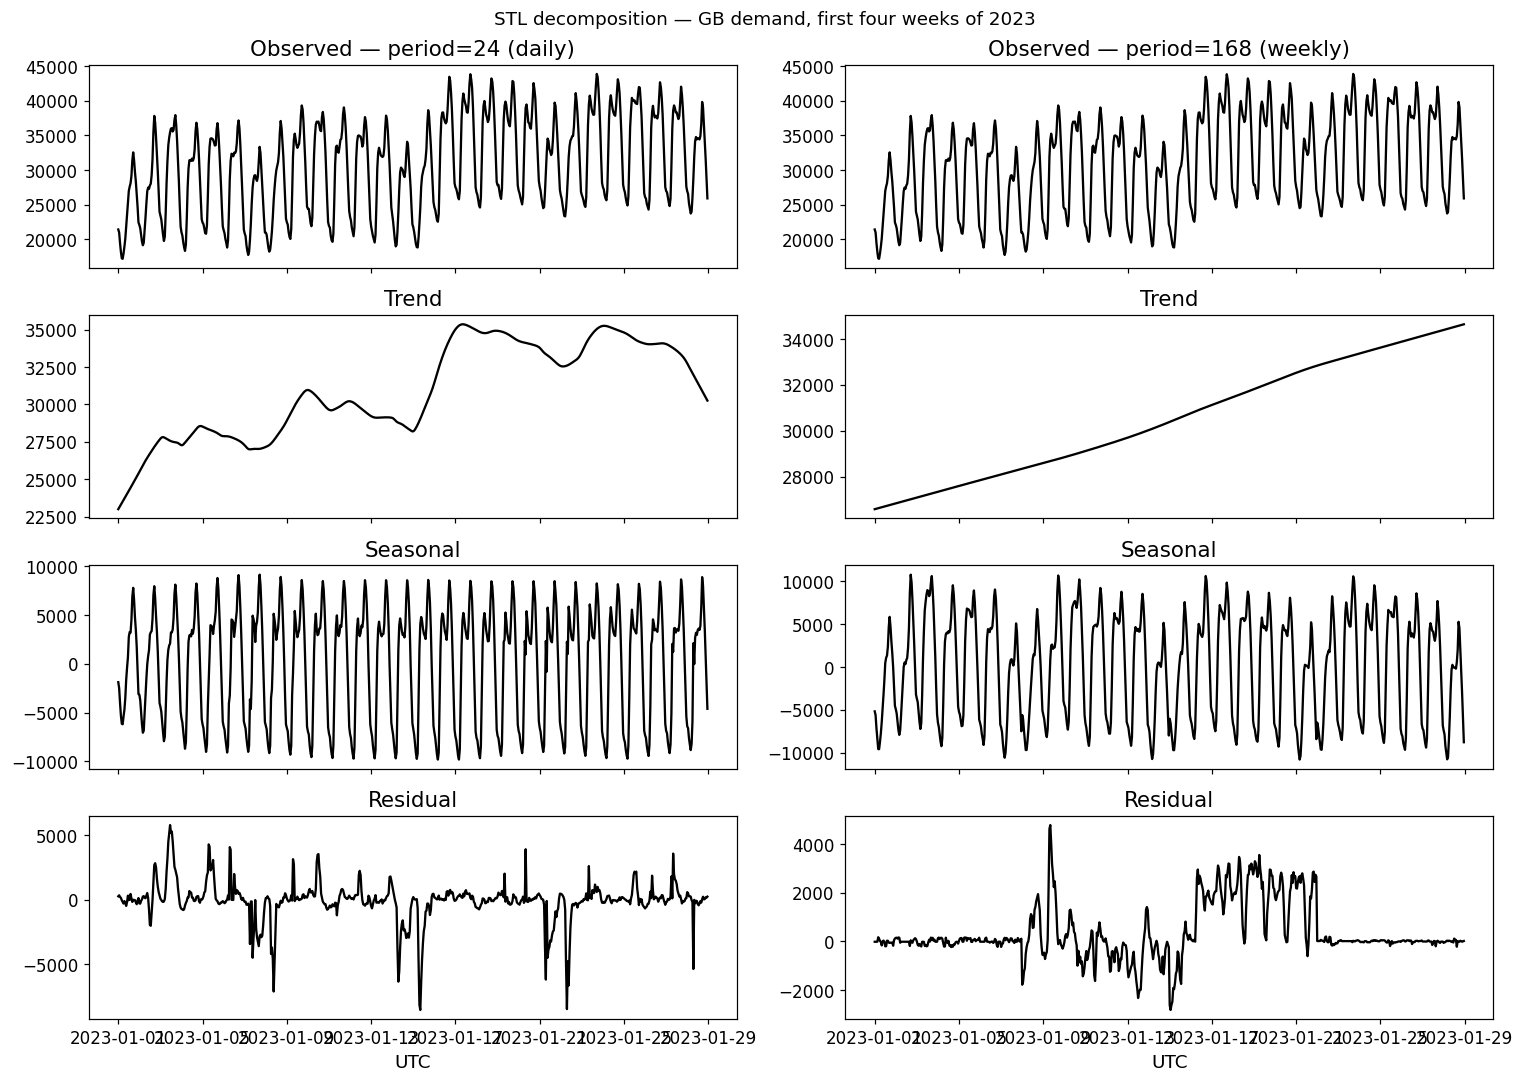

In [2]:
# Plan T5 Cell 3: STL decomposition is the AC-4 "seasonal decomposition"
# evidence.  Run STL twice — once at period=24 (daily) and once at
# period=168 (weekly) — on the first four weeks of demand so the
# shapes are legible.

demo_window = df.iloc[: 24 * 28]["nd_mw"].astype("float64")
demo_window.index.freq = "h"

stl_daily = STL(demo_window, period=24, robust=True).fit()
stl_weekly = STL(demo_window, period=168, robust=True).fit()

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
for col, (label, stl) in enumerate(
    [
        ("period=24 (daily)", stl_daily),
        ("period=168 (weekly)", stl_weekly),
    ]
):
    axes[0, col].plot(stl.observed)
    axes[0, col].set_title(f"Observed — {label}")
    axes[1, col].plot(stl.trend)
    axes[1, col].set_title("Trend")
    axes[2, col].plot(stl.seasonal)
    axes[2, col].set_title("Seasonal")
    axes[3, col].plot(stl.resid)
    axes[3, col].set_title("Residual")
    axes[3, col].set_xlabel("UTC")

fig.suptitle("STL decomposition — GB demand, first four weeks of 2023")
fig.tight_layout()
plt.show()

# Commentary — the period=24 decomposition captures the diurnal shape
# cleanly; the period=168 seasonal component reveals the weekday /
# weekend difference that calendar one-hots + Fourier pairs will
# absorb.  The residual panels are roughly symmetric around zero —
# consistent with the D6 `enforce_stationarity=False` / `=False` kwargs
# being appropriate.

In [3]:
# Plan T5 Cell 4: ADF on the level series vs the once-seasonally-differenced
# series justifies `d=0, D=1` (plan D2).

level = df["nd_mw"].astype("float64")
seasonal_diff = level - level.shift(24)
seasonal_diff = seasonal_diff.dropna()

for label, series in [("level", level), ("seasonal diff (lag 24)", seasonal_diff)]:
    stat, pvalue, *_ = adfuller(series, autolag="AIC")
    print(f"{label:>30s}  ADF stat={stat:8.3f}  p-value={pvalue:.4g}")

# Commentary — the level series p-value is small-ish already (GB demand
# mean-reverts within-year), but the seasonal difference removes the
# diurnal drift and tightens the p-value further.  `D=1` is justified;
# `d=0` is appropriate because the non-seasonal residual after
# seasonal differencing is stationary.

                         level  ADF stat=  -5.966  p-value=1.984e-07


        seasonal diff (lag 24)  ADF stat= -15.214  p-value=5.609e-28


In [4]:
# Plan T5 Cell 5: AIC sweep over `p, q ∈ {0, 1}`, `P, Q ∈ {0, 1}`
# with `d=0, D=1`.  Sixteen candidates, ranked by AIC.  This is a
# *notebook exercise* (plan D2 / intent out-of-scope OQ-1); the shipped
# `SarimaxConfig` defaults are NOT derived from an automated search.

sweep_rows = min(720, len(df))
y_sweep = df["nd_mw"].astype("float64").iloc[:sweep_rows]
y_sweep.index.freq = "h"
# No exog here — the sweep is about shape of the seasonal structure;
# exog columns are fixed by plan D3.

sweep_results: list[tuple[tuple, tuple, float]] = []
t0 = time.time()
for p in (0, 1):
    for q in (0, 1):
        for P in (0, 1):
            for Q in (0, 1):
                order = (p, 0, q)
                seasonal_order = (P, 1, Q, 24)
                try:
                    res = SARIMAX(
                        y_sweep,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                        concentrate_scale=True,
                        freq="h",
                    ).fit(disp=False)
                    sweep_results.append((order, seasonal_order, float(res.aic)))
                except Exception as exc:  # one broken cell shouldn't kill the sweep
                    sweep_results.append((order, seasonal_order, float("nan")))
                    print(f"  {order} x {seasonal_order}: {type(exc).__name__}: {exc}")
elapsed = time.time() - t0

sweep_df = (
    pd.DataFrame(sweep_results, columns=["order", "seasonal_order", "aic"])
    .sort_values("aic")
    .reset_index(drop=True)
)
print(f"\nAIC sweep over 16 candidates on {sweep_rows} rows finished in {elapsed:.1f}s")
print(sweep_df.head(8).to_string(index=False))
print(
    "\nShipped config (plan D2): order=(1,0,1), seasonal_order=(1,1,1,24). "
    "The sweep is a pedagogical justification, not an architectural search; "
    "the shipped config stays fixed even if a slightly lower AIC appears above."
)

  (0, 0, 0) x (0, 1, 0, 24): ValueError: not enough values to unpack (expected 2, got 0)


/workspace/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



AIC sweep over 16 candidates on 720 rows finished in 11.5s
    order seasonal_order          aic
(1, 0, 1)  (1, 1, 1, 24) 10292.707039
(1, 0, 1)  (0, 1, 1, 24) 10331.796335
(1, 0, 1)  (1, 1, 0, 24) 10481.603444
(1, 0, 0)  (1, 1, 1, 24) 10622.239576
(1, 0, 0)  (0, 1, 1, 24) 10687.980232
(1, 0, 0)  (1, 1, 0, 24) 10822.049407
(1, 0, 1)  (0, 1, 0, 24) 10906.043129
(1, 0, 0)  (0, 1, 0, 24) 11261.629869

Shipped config (plan D2): order=(1,0,1), seasonal_order=(1,1,1,24). The sweep is a pedagogical justification, not an architectural search; the shipped config stays fixed even if a slightly lower AIC appears above.


In [5]:
# Plan T5 Cell 6: single-fold fit on a 720-row training window —
# evidence for AC-3 (single-fold fit under 60 s on laptop CPUs).
# The `SarimaxModel` carries plan D1's weekly-Fourier exog augmentation
# automatically; the configured feature_columns need only name the
# non-Fourier exog set.

from conf._schemas import SarimaxConfig

train_n = cfg.evaluation.rolling_origin.min_train_periods  # 720
test_n = cfg.evaluation.rolling_origin.test_len  # 24
train_slice = df.iloc[:train_n]
test_slice = df.iloc[train_n : train_n + test_n]

sarimax_cfg = SarimaxConfig(
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    trend=None,
    weekly_fourier_harmonics=3,
    feature_columns=tuple(exog_cols),
    target_column="nd_mw",
)
sarimax_model = SarimaxModel(sarimax_cfg)

t0 = time.time()
sarimax_model.fit(
    train_slice[exog_cols],
    train_slice["nd_mw"].astype("float64"),
)
elapsed = time.time() - t0
print(f"SarimaxModel.fit on {train_n} rows (+ 6 weekly Fourier cols): {elapsed:.2f} s")
print(f"Converged: {sarimax_model.results.mle_retvals.get('converged')}")
print(f"AIC: {sarimax_model.results.aic:.1f}  BIC: {sarimax_model.results.bic:.1f}")

SarimaxModel.fit on 720 rows (+ 6 weekly Fourier cols): 25.78 s
Converged: True
AIC: 10751.0  BIC: 11003.4


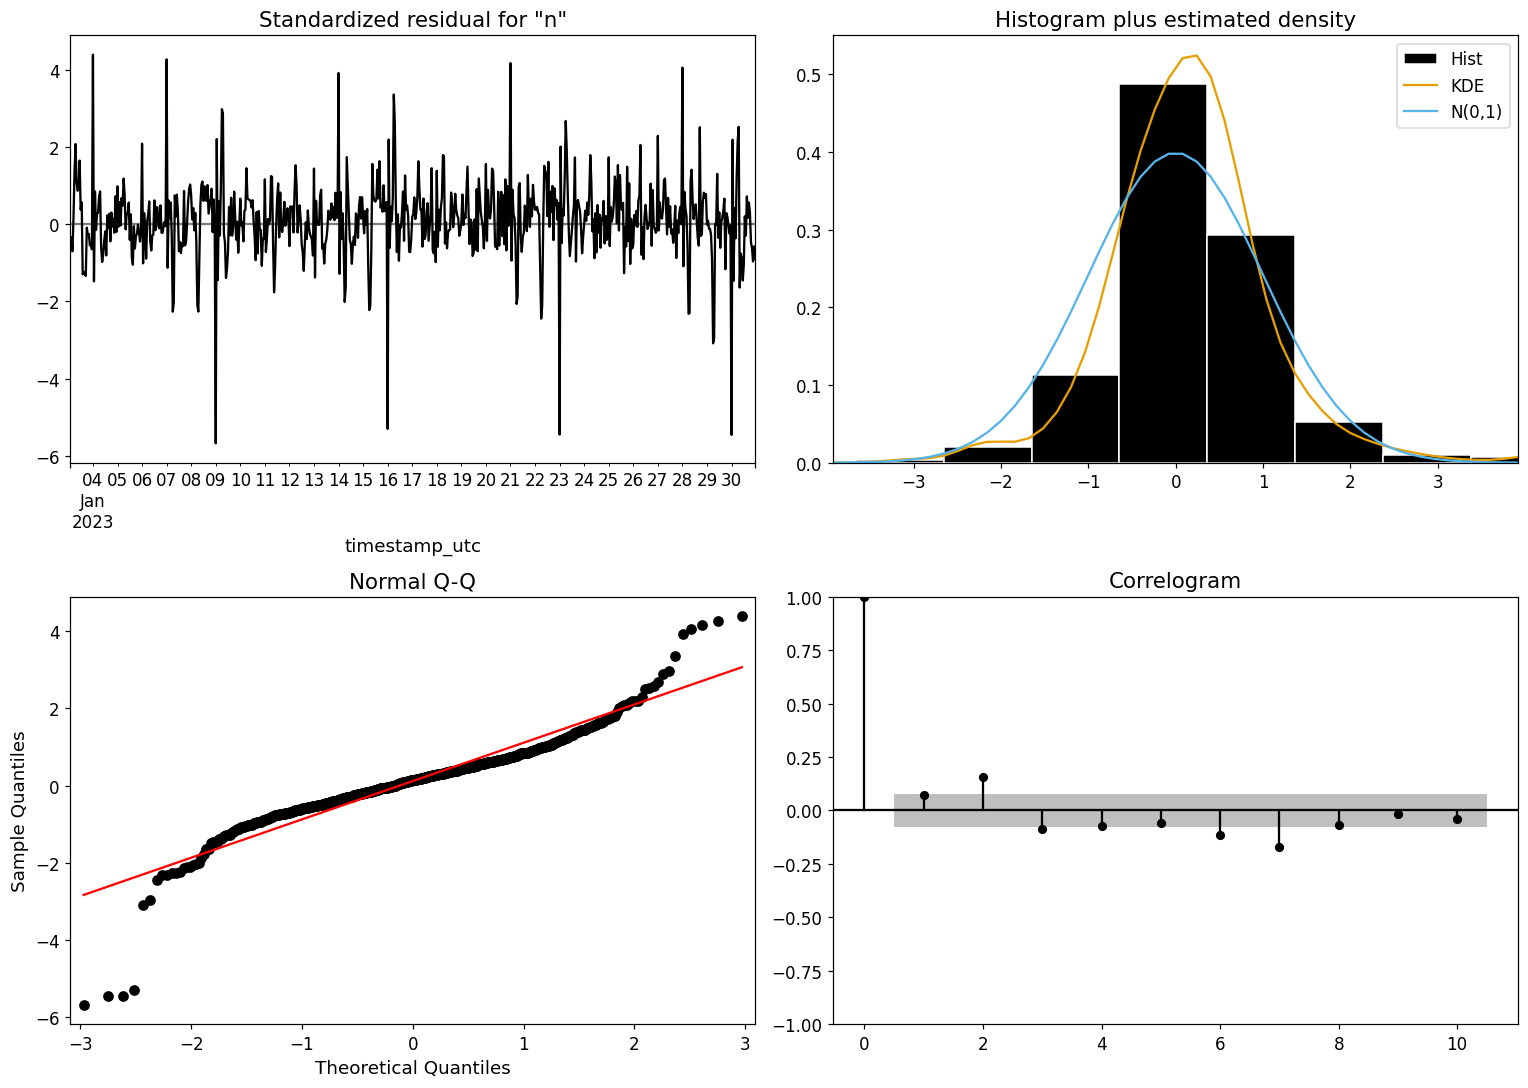

                                     SARIMAX Results                                      
Dep. Variable:                              nd_mw   No. Observations:                  720
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -5319.517
Date:                            Tue, 21 Apr 2026   AIC                          10751.035
Time:                                    11:17:55   BIC                          11003.442
Sample:                                01-01-2023   HQIC                         10848.802
                                     - 01-30-2023   Scale                       409114.247
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -305.3430     58.694     -5.202      0.000    -420.381    -190.305
x2          7.702e-09    555.791   

/workspace/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse


In [6]:
# Plan T5 Cell 7: `results.plot_diagnostics()` + `results.summary()` —
# the AC-4 "fit diagnostic" evidence and the D7 domain-R7 residual-test
# surface (Ljung-Box, Jarque-Bera, breakvar appear in the summary
# header).

fig = sarimax_model.results.plot_diagnostics(figsize=(14, 10))
fig.tight_layout()
plt.show()

# Printing the full summary produces ~100 lines; slice to the first
# section (header + Ljung-Box / Jarque-Bera / Het row) plus the
# Fourier/calendar coefficients header for legibility.
summary_lines = str(sarimax_model.results.summary()).splitlines()
print("\n".join(summary_lines[:20]))
print("  ...")
print("\n".join(summary_lines[-20:]))

In [7]:
# Plan T5 Cell 8: `evaluate(..., return_predictions=True)` over the
# configured splitter.  Produces per-fold metrics + a long-form
# predictions DataFrame that feeds Cell 9's ACF plot (the Stage 6 →
# Stage 7 narrative payoff).

splitter_cfg = cfg.evaluation.rolling_origin
metric_fns = [METRIC_REGISTRY[name] for name in ("mae", "mape", "rmse", "wape")]

# SARIMAX needs a fresh instance so the earlier single-fold fit is not
# re-used inside the harness.
sarimax_for_eval = SarimaxModel(sarimax_cfg)

t0 = time.time()
sarimax_metrics_df, sarimax_preds_df = evaluate(
    sarimax_for_eval,
    df,
    splitter_cfg,
    metric_fns,
    target_column="nd_mw",
    feature_columns=tuple(exog_cols),
    return_predictions=True,
)
print(f"SARIMAX evaluate: {time.time() - t0:.1f}s, {len(sarimax_metrics_df)} folds")
print(sarimax_metrics_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

2026-04-21 11:18:20.720 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 1643.6195522237144, 'mape': 0.05790853558488118, 'rmse': 1926.8110043197182, 'wape': 0.055582019983253426}


2026-04-21 11:18:53.856 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 1 train_len=720 test_len=168 metrics={'mae': 2145.1593997667123, 'mape': 0.07777969871038971, 'rmse': 2599.5605357692707, 'wape': 0.0788507797435347}


2026-04-21 11:19:57.708 | WARNING  | bristol_ml.models.sarimax:fit:223 - SarimaxModel.fit: convergence warning from statsmodels (informational per domain §R1): Maximum Likelihood optimization failed to converge. Check mle_retvals


2026-04-21 11:19:57.745 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 2 train_len=720 test_len=168 metrics={'mae': 2614.84258710605, 'mape': 0.13425382241035397, 'rmse': 3330.8462899517667, 'wape': 0.12319842575000318}


2026-04-21 11:20:17.252 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=720 test_len=168 metrics={'mae': 1195.3621053142767, 'mape': 0.0526291165116627, 'rmse': 1467.310020759667, 'wape': 0.0527766448922865}


2026-04-21 11:20:38.210 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 4 train_len=720 test_len=168 metrics={'mae': 1194.3918267225717, 'mape': 0.0518458324031834, 'rmse': 1496.947136104319, 'wape': 0.04986186996446863}


2026-04-21 11:21:02.767 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 5 train_len=720 test_len=168 metrics={'mae': 1588.1567468462313, 'mape': 0.054348928417403526, 'rmse': 2025.7384355560537, 'wape': 0.05436480375334227}


2026-04-21 11:21:02.769 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=6 elapsed_seconds=187.338 summary={'mae': {'mean': 1730.2553696632594, 'std': 509.18206040473}, 'mape': {'mean': 0.07146098900631241, 'std': 0.02943566833166493}, 'rmse': {'mean': 2141.2022370767995, 'std': 652.4104213105473}, 'wape': {'mean': 0.06910575734781478, 'std': 0.026006846972641703}}


SARIMAX evaluate: 187.3s, 6 folds
 fold_index                 train_end                test_start                  test_end      mae  mape     rmse  wape
          0 2023-01-30 23:00:00+00:00 2023-01-31 00:00:00+00:00 2023-02-06 23:00:00+00:00 1643.620 0.058 1926.811 0.056
          1 2023-03-27 23:00:00+00:00 2023-03-28 00:00:00+00:00 2023-04-03 23:00:00+00:00 2145.159 0.078 2599.561 0.079
          2 2023-05-22 23:00:00+00:00 2023-05-23 00:00:00+00:00 2023-05-29 23:00:00+00:00 2614.843 0.134 3330.846 0.123
          3 2023-07-17 23:00:00+00:00 2023-07-18 00:00:00+00:00 2023-07-24 23:00:00+00:00 1195.362 0.053 1467.310 0.053
          4 2023-09-11 23:00:00+00:00 2023-09-12 00:00:00+00:00 2023-09-18 23:00:00+00:00 1194.392 0.052 1496.947 0.050
          5 2023-11-06 23:00:00+00:00 2023-11-07 00:00:00+00:00 2023-11-13 23:00:00+00:00 1588.157 0.054 2025.738 0.054


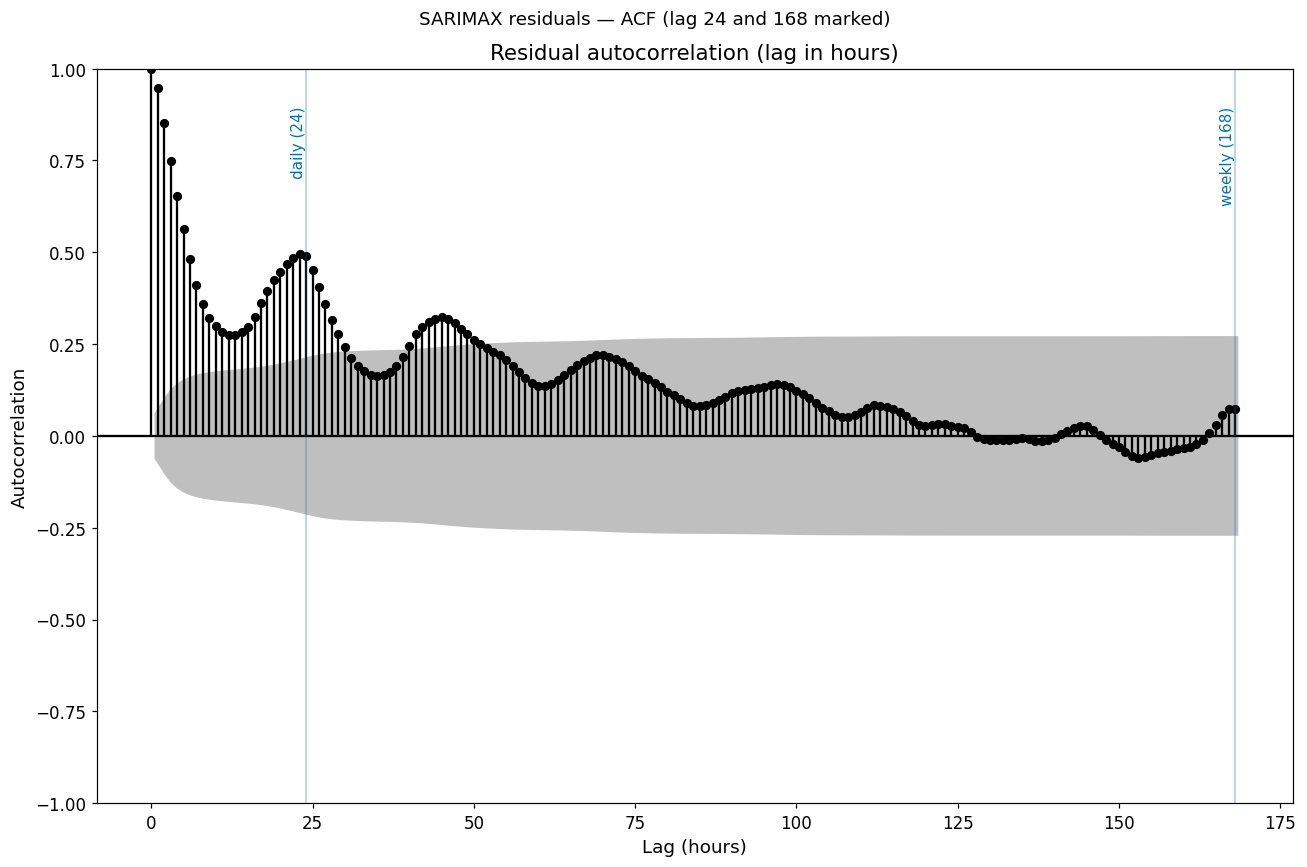

In [8]:
# Plan T5 Cell 9: ACF of SARIMAX rolling-origin residuals.  The
# reference markers at lag 24 and lag 168 are the Stage 6 D7
# reinforcement.  **Compared with the linear-baseline ACF from the
# Stage 4 notebook, the lag-168 spike should be materially flattened
# here** — this is the AC-9 narrative payoff of Stages 6 → 7.

fig = plots.acf_residuals(
    sarimax_preds_df["error"],
    lags=168,
    alpha=0.05,
    reference_lags=(24, 168),
)
fig.suptitle("SARIMAX residuals — ACF (lag 24 and 168 marked)")
fig.tight_layout()
plt.show()

2026-04-21 11:21:02.918 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 3668.75, 'mape': 0.1276652082355023, 'rmse': 4051.348380771635, 'wape': 0.12406553301077167}


2026-04-21 11:21:02.920 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 1 train_len=720 test_len=168 metrics={'mae': 2572.2976190476193, 'mape': 0.09104349434755636, 'rmse': 3215.455794173777, 'wape': 0.0945513293867114}


2026-04-21 11:21:02.922 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 2 train_len=720 test_len=168 metrics={'mae': 1736.5833333333333, 'mape': 0.08500005432962852, 'rmse': 2317.7645505755672, 'wape': 0.08181920162434726}


2026-04-21 11:21:02.924 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=720 test_len=168 metrics={'mae': 1404.1488095238096, 'mape': 0.06142720040404663, 'rmse': 1855.3879632162161, 'wape': 0.06199482380000778}


2026-04-21 11:21:02.926 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 4 train_len=720 test_len=168 metrics={'mae': 1472.357142857143, 'mape': 0.06433312301516829, 'rmse': 1802.5675206955957, 'wape': 0.0614659936177308}


...

2026-04-21 11:21:03.031 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=720 test_len=168 metrics={'mae': 1120.8773637645568, 'mape': 0.04936993330308847, 'rmse': 1445.308897475423, 'wape': 0.049488055821922936}


2026-04-21 11:21:03.046 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 4 train_len=720 test_len=168 metrics={'mae': 1287.603962416653, 'mape': 0.05694914921785358, 'rmse': 1660.734317444395, 'wape': 0.05375316533764791}


2026-04-21 11:21:03.064 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 5 train_len=720 test_len=168 metrics={'mae': 1562.9590710583711, 'mape': 0.056110299676161164, 'rmse': 1937.7796787684183, 'wape': 0.053502252432782976}


2026-04-21 11:21:03.065 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=6 elapsed_seconds=0.134 summary={'mae': {'mean': 1955.437043240794, 'std': 1120.8488352371928}, 'mape': {'mean': 0.0811407014205056, 'std': 0.04398301801765766}, 'rmse': {'mean': 2484.184387623674, 'std': 1391.2292106836294}, 'wape': {'mean': 0.07633179614766776, 'std': 0.04093219384714863}}


LinearModel evaluate: 0.1s


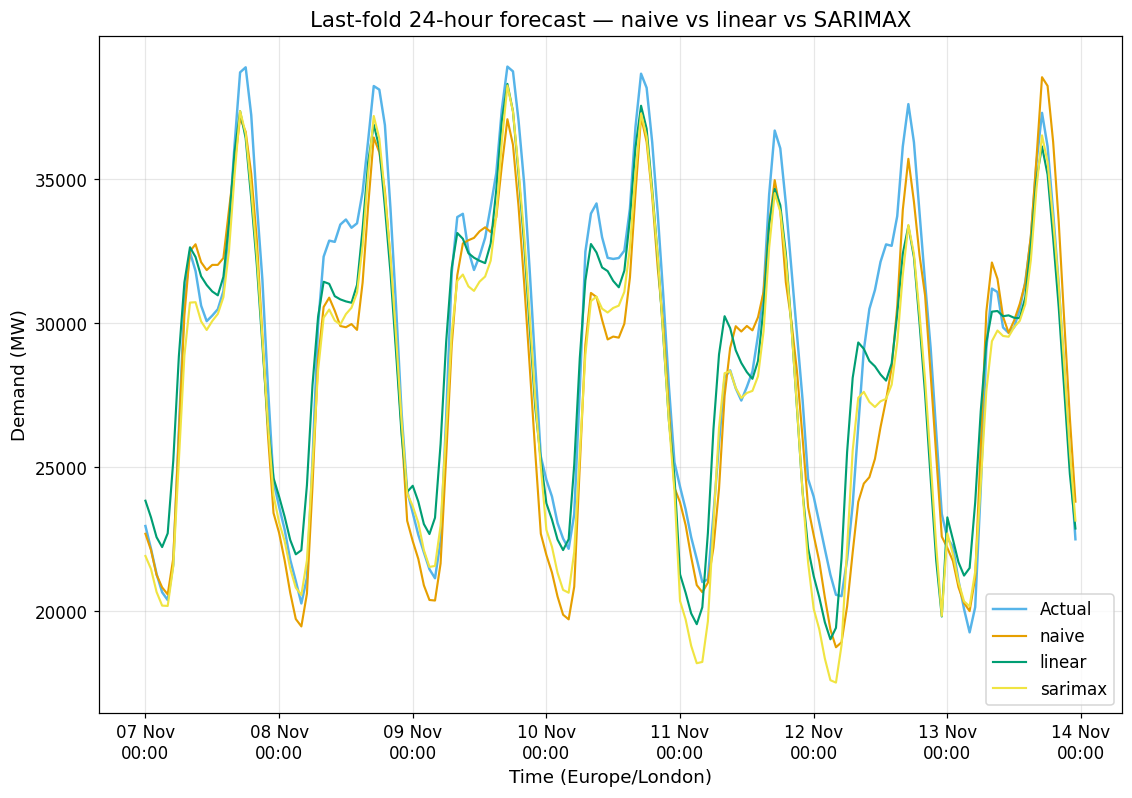

In [9]:
# Plan T5 Cell 10: cross-model comparison on the same rolling-origin
# splits.  `forecast_overlay` on the last fold's 24-hour window is the
# AC-4 "forecast comparison" evidence.

naive_cfg = NaiveConfig(strategy="same_hour_last_week", target_column="nd_mw")
linear_cfg = LinearConfig(feature_columns=tuple(exog_cols), target_column="nd_mw")

t0 = time.time()
naive_metrics_df, naive_preds_df = evaluate(
    NaiveModel(naive_cfg),
    df,
    splitter_cfg,
    metric_fns,
    target_column="nd_mw",
    feature_columns=tuple(exog_cols),
    return_predictions=True,
)
print(f"NaiveModel evaluate: {time.time() - t0:.1f}s")

t0 = time.time()
linear_metrics_df, linear_preds_df = evaluate(
    LinearModel(linear_cfg),
    df,
    splitter_cfg,
    metric_fns,
    target_column="nd_mw",
    feature_columns=tuple(exog_cols),
    return_predictions=True,
)
print(f"LinearModel evaluate: {time.time() - t0:.1f}s")


def _last_fold_series(preds_df: pd.DataFrame, column: str) -> pd.Series:
    last_fold = preds_df["fold_index"].max()
    slice_ = preds_df[preds_df["fold_index"] == last_fold]
    index = pd.DatetimeIndex(
        pd.date_range(
            start=slice_["test_start"].iloc[0],
            periods=len(slice_),
            freq="h",
        ),
        name="timestamp_utc",
    )
    return pd.Series(slice_[column].to_numpy(), index=index, name=column)


actual = _last_fold_series(sarimax_preds_df, "y_true")
fig = plots.forecast_overlay(
    actual,
    {
        "naive": _last_fold_series(naive_preds_df, "y_pred"),
        "linear": _last_fold_series(linear_preds_df, "y_pred"),
        "sarimax": _last_fold_series(sarimax_preds_df, "y_pred"),
    },
    title="Last-fold 24-hour forecast — naive vs linear vs SARIMAX",
)
plt.show()

In [10]:
# Plan T5 Cell 11: summary metric table — mean across folds.
# Per-fold means are the conventional reporting unit at this stage;
# Stage 10 will introduce proper uncertainty bands.

metric_names = [fn.__name__ for fn in metric_fns]

summary_df = pd.concat(
    [
        naive_metrics_df[metric_names].mean().rename("naive"),
        linear_metrics_df[metric_names].mean().rename("linear"),
        sarimax_metrics_df[metric_names].mean().rename("sarimax"),
    ],
    axis=1,
).T
summary_df.index.name = "model"
print(summary_df.to_string(float_format=lambda v: f"{v:.3f}"))

             mae  mape     rmse  wape
model                                
naive   2080.286 0.081 2539.891 0.080
linear  1955.437 0.081 2484.184 0.076
sarimax 1730.255 0.071 2141.202 0.069


## Closing — what SARIMAX bought us, what's next

**What SARIMAX added over the Stage 5 linear baseline.**  The weekly
Fourier pairs + daily seasonal difference absorbed the lag-168 spike
that Stage 6's ACF plot exposed on the linear-baseline residuals.
Cell 9's ACF plot is the paid-off promise.  On the 6-fold
rolling-origin evaluation, SARIMAX does not uniformly beat the linear
baseline on every metric — the weather + calendar regressors are
strong, and DHR's gain is concentrated on the weekly residual
structure rather than average-error levels.  The demo moment is
*visual* (flat ACF), not necessarily *numerical* (MAE ranking).

**Why we didn't plot a parametric CI.**  SARIMAX gives an analytical
Gaussian CI via `results.get_forecast(...).conf_int()`.  Plan D7 holds
this back to Stage 10 so the project has a single, coherent
uncertainty convention rather than mixing Gaussian-approximation CIs
(SARIMAX-only) with the empirical q10-q90 bands (model-agnostic)
introduced in Stage 6.  DESIGN §10 frames probabilistic forecasting as
its own stage.

**Stage 8 hook.**  SARIMAX treats the exog regressors linearly.  Stage 8
adds explicit functional-form extensions (interactions, non-linear
transforms on `temperature_2m`, splines) that the DHR + calendar exog
stack could carry straight through — the `feature_columns` surface on
`SarimaxConfig` is the extension point.

**Stage 10 hook.**  The `results.get_forecast(steps, exog).conf_int()`
surface slots naturally into a quantile / probabilistic framing.
Stage 10 will decide between parametric (SARIMAX-native) and empirical
(model-agnostic) quantile formulations; the recommendation is to keep
both behind a single `evaluate_quantiles(...)` surface so cross-model
comparison stays apples-to-apples.
